# Experiment #2:

During the conducted error analysis after the first experiment we observed redundancies in paths between items to their parents and grand parents. Items were in big ratio connected to their grand parents and parents, which in consequence made the model learn a popularity bias. In this experiment we observe if the updated taxonomy, created by the LLM-COL-Hierarchy-Tax using the LLM gemma3-3b, helps improving performances metrices while learning distinct user preferences. 

**Data:**
We will use the `Amazon Video Games` dataset from the first experiment in a 5-core setting.

**Techniques:**
As technique for creating the taxonomies we use the `LLMHierarchyCOL` technique from the first experiment with the removed redundancies.

**Hyperparameters:**
While train and testing we apply for the hyperparemter `n_hops` four different values: `3`, `5`, `7`, `9`, `11` and `13`. This is to observe if the model performances is correlated to the amount of entities it is able to explore before making a prediciton.

**Evaluation**:
_Quantitative:_
- Performance: To evaluate the performance of the techniques we will use the `KGIL` model as baseline model. We will evaluate the performance of the techniques by measuring the `Precision@20`, `Recall@20`, `NDCG@20` and `Hit Ratio@20`.
- Cost: We measure the time consumption to model the taxonomies and train the KGIL model for each technique and the memory footprint.

_Qualitative:_
- Taxonomy quality: We observe the quality of the generated taxonomies by visualizing them. 
- Error analysis: We conduct an error analysis on the KGIL model for each technique. This will help identify if the taxonomies are useful during the multi-hop reasoning of the KGIL model. Also it help identify if KGIL systematically predicts errors for certain entities.

**Infrastructure:**
The experiments were conducted on a Apple M2 MacBook Pro with 16GB RAM and 10-core CPU.


## 0. Setup

In [1]:
import os # path management
import sys # system path management
import pandas as pd # data manipulation
import numpy as np # data manipulation
from scipy.sparse import csr_matrix # build adjency matrix
import random # random number generation
import torch # for gnn
import networkx as nx # graph library
from sentence_transformers import SentenceTransformer # 

from time import time # time measurement
import Levenshtein # levenshtein distance


sys.path.append('../..')  # Add the project root to the path so we can import from utils

from utils.data_processing import Build_KG


### Hyperparameters

+ DATASET: _this hyperparameter is used to find the preprocessed dataset in the data/preprocessed folder. aswell it used to find the relations in the data/relations folder and create an experiment folder in the data/experiments folder._

+ MODEL_TECHNIQUE: _this hyperparameter is used to find the model technique in the MODEL_TECHNIQUES list. this is the second parameter in the data path to find preprocessed  and relations data and to store results._

+ EXPERIMENT_NAME: _this hyperparameter is used to create an experiment folder in the data/experiments folder. the experiment name is used to store the results of the experiment._

+ KNOWLEDGE GRAPH HYPERPARAMETERS: 
    + BATCH_SIZE: _this hyperparameter is used to set the batch size for the KGIL model. the batch size is used to train the KGIL model._
    + EPOCHS: _this hyperparameter is used to set the number of epochs for the KGIL model. the number of epochs is used to train the KGIL model._
    + TEST_BATCH_SIZE: _this hyperparameter is used to set the batch size for the KGIL model. the batch size is used to train the KGIL model._


In [2]:
# --- Configuration ---
# Set the desired data path, dataset name and model technique here
# Example: Use the 'amazon-All_Beauty' dataset located two levels up in 'data'
DATASETS = ["Books", "amazon-All_Beauty", "amazon-Video_Games","Last-FM"]
DATASET = DATASETS[2]

current_dir = os.getcwd()
project_root = os.path.dirname(os.path.dirname(os.path.dirname(current_dir)))

MODEL_TECHNIQUE = "gemma3"

EXPERIMENT_NAME = "#2 Taxonomy without redundancies at 1000 epochs"
EXPERIMENT_DATA_PATH = os.path.join(project_root, 'data', 'experiments',EXPERIMENT_NAME,DATASET,MODEL_TECHNIQUE)

EPOCH = "120" # set epochs small, because the dataset is large
BATCH_SIZE = "512" # set batch size high, because the dataset is large
TEST_BATCH_SIZE = "512"




## 2. Experiment

### 2.1 LLM-Col-Hierarchy-Tax (Gemma 3) without redundancies


Starting build_kg. Output path: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#2 Taxonomy without redundancies - Full/amazon-Video_Games/gemma3
Combined KG has 181644 unique triples.
Found 23900 unique entities.
Found 3 unique relations.
Mapped 130700 train interactions.
Mapped 5380 test interactions.
Mapped KG has 181644 triples.
Writing training interactions to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#2 Taxonomy without redundancies - Full/amazon-Video_Games/gemma3/train_adj.txt
Writing testing interactions to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#2 Taxonomy without redundancies - Full/amazon-Video_Games/gemma3/test_adj.txt
Writing mapped KG triples to: /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/experiments/#2 Taxonomy without redundancies - Full/amazon-Video_Games/gemma3/kg_final.txt
Saved mapping files to /Users/U725801/Documents/GitHub/Masterarbeit-Playground/data/ex

100%|##########| 3990/3990 [00:00<00:00, 1692140.85it/s]



Begin to load knowledge graph triples ...


100%|##########| 363288/363288 [00:01<00:00, 260358.06it/s]


End to build graph ... MultiDiGraph with 23900 nodes and 363288 edges
building the adj mat ...
Begin to build sparse relation matrix ...


...


Begin to load knowledge graph triples ...


100%|##########| 363288/363288 [00:01<00:00, 328260.37it/s]


End to build graph ... MultiDiGraph with 23900 nodes and 363288 edges
building the adj mat ...
Begin to build sparse relation matrix ...


100%|██████████| 7/7 [00:00<00:00, 72.97it/s]


Density of the graph: 0.0006360238808332346
Average degree of the graph: 30.400669456066947
Max degree of the graph: 24212
Dataset statistics:
Number of training interactions: 3990
Number of test interactions: 813
Number of users: 4047
Number of items: 23866
Batch size: 512
start training ...

Epoch 1/120
Number of iterations expected: 7
Processing 3990 samples in batches of 512

First batch statistics:
Users shape: torch.Size([512])
Positive items shape: torch.Size([512])
Negative items shape: torch.Size([512])

Iteration 0 losses:
rec_loss: 0.435510
inv_mean: 3.773728
inv_var: 0.007330
outer_loss: 0.473320

Gradient norms:
all_embed: 10.546177
latent_emb: 0.000660
gcn.weight: 1.179478
gcn.disen_weight_att: 0.002648
gcn.invariant_generator.kg_W_r: 0.000012
augmenter.edge_mlp_list.0.0.weight: 0.000517
augmenter.edge_mlp_list.0.0.bias: 0.000274
augmenter.edge_mlp_list.0.2.weight: 0.000204
augmenter.edge_mlp_list.0.2.bias: 0.000117
augmenter.edge_mlp_list.1.0.weight: 0.000600
augmenter.e

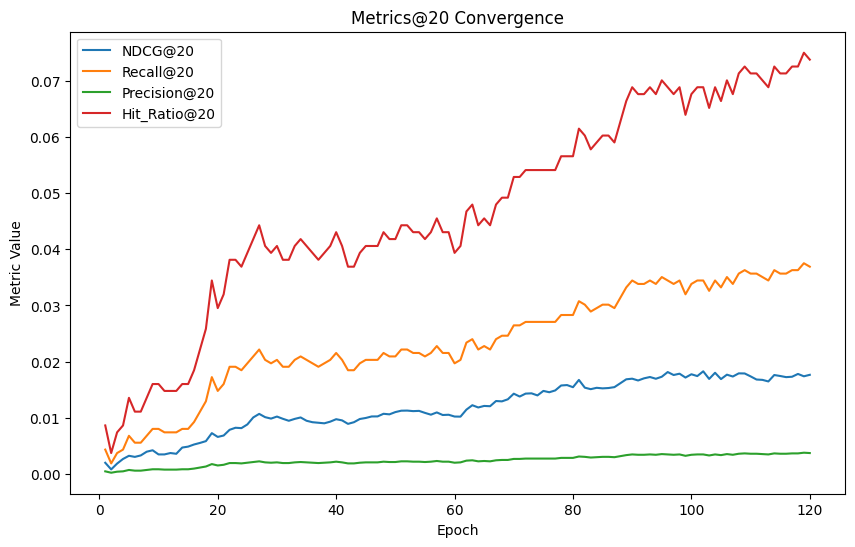

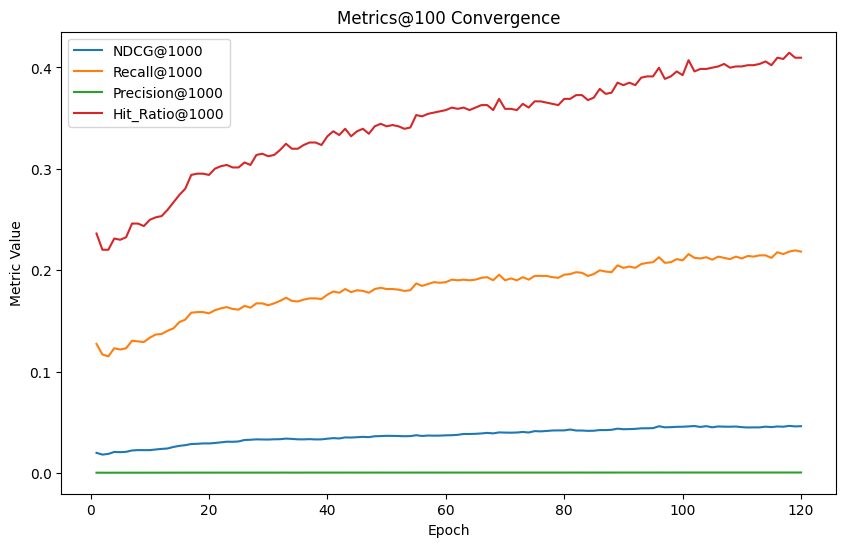

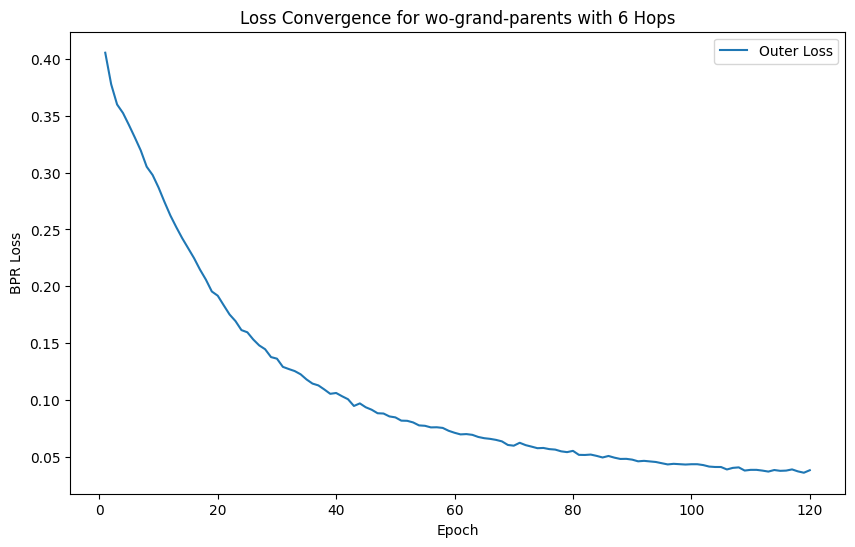

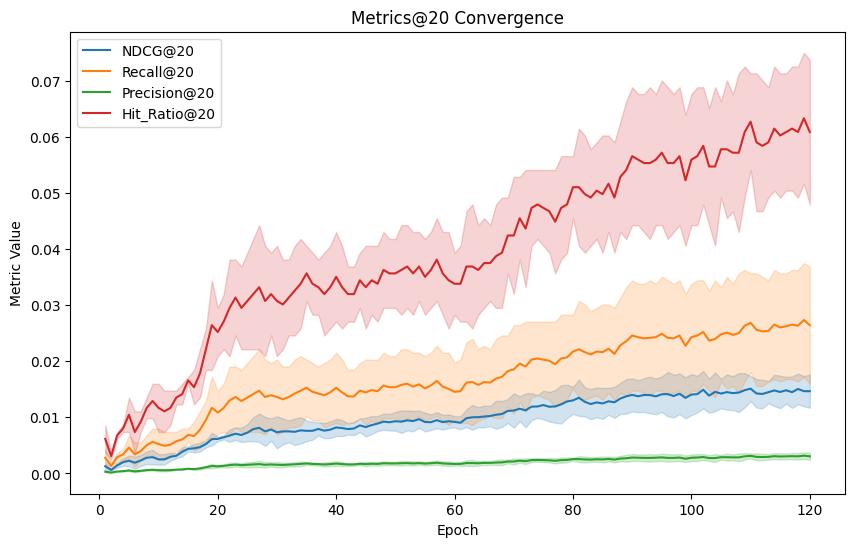

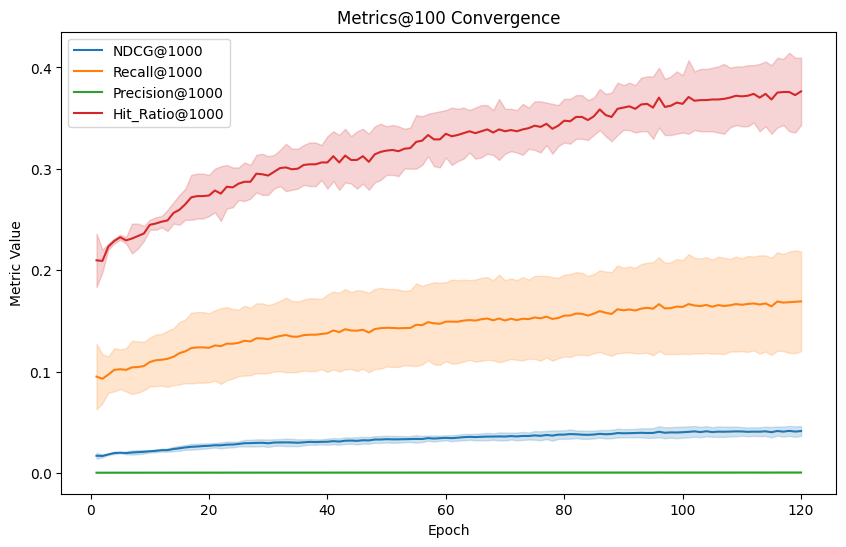

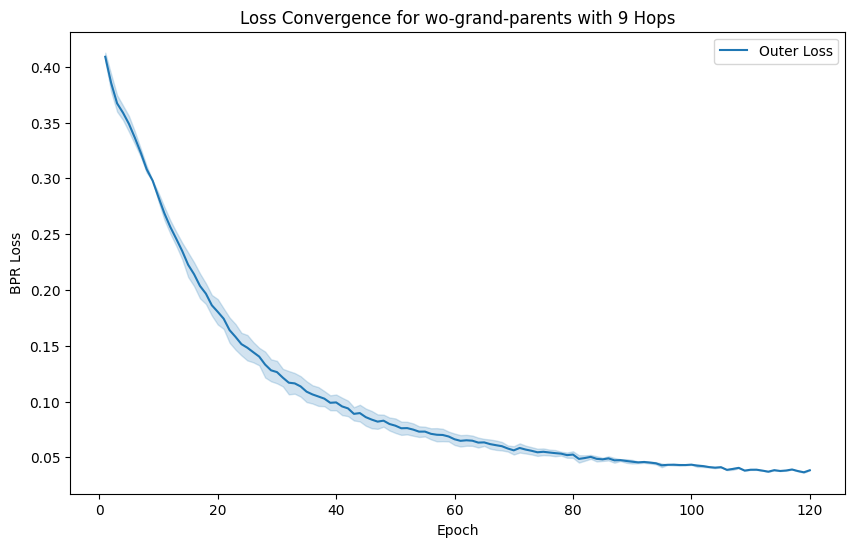

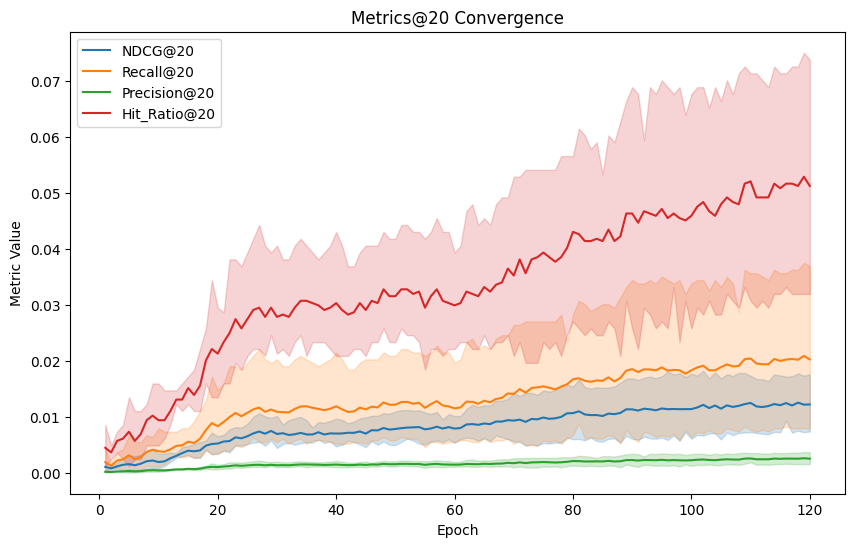

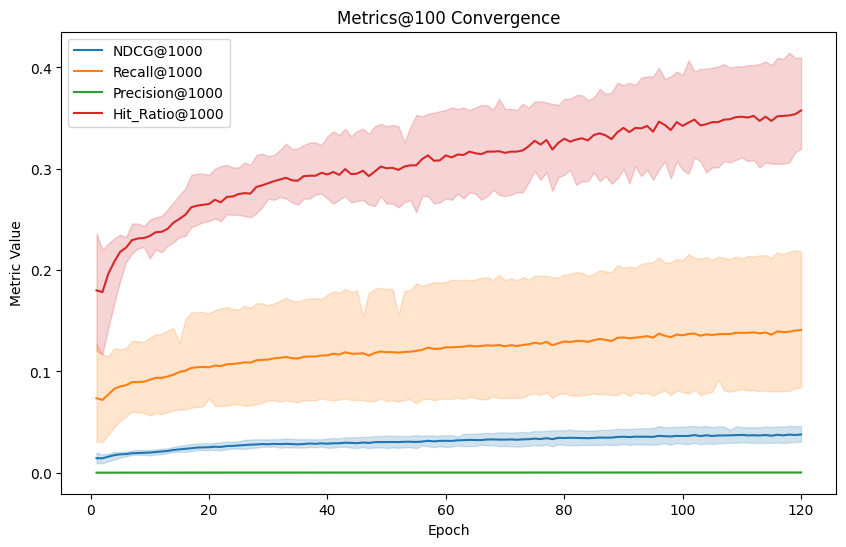

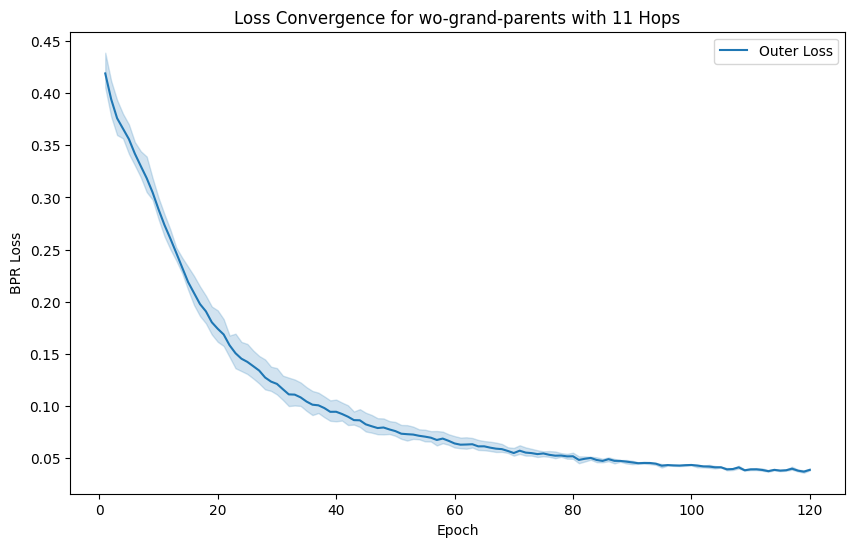

In [ ]:

sys.path.append('../../src/models/KGIL')
from prettytable import PrettyTable
from models.KGIL.utils.parser import parse_args
from models.KGIL.utils.data_loader import load_data
from models.KGIL.utils.evaluate_kgil import test
from models.KGIL.utils.helper import early_stopping
from models.KGIL.model import EnvGenerator, Recommender
import matplotlib.pyplot as plt
import seaborn as sns

# --- Dynamic Argument Setting ---
# Store the original sys.argv
original_argv = sys.argv.copy()

# Clear existing arguments (except the script name itself) and add the desired ones
sys.argv = [sys.argv[0]]
sys.argv.extend(['--dataset', DATASET])
sys.argv.extend(['--model_technique', MODEL_TECHNIQUE])
sys.argv.extend(['--batch_size', BATCH_SIZE])
sys.argv.extend(['--epoch', EPOCH])
sys.argv.extend(['--test_batch_size', TEST_BATCH_SIZE])
sys.argv.extend(['--lr', "1e-3"])

# Add data path argument
sys.argv.extend(['--data_path', EXPERIMENT_DATA_PATH])

# Initialize global variables
n_items = 0
n_entities = 0
n_nodes = 0
n_relations = 0

def get_feed_dict(train_entity_pairs, start, end, train_user_set):
    def negative_sampling(user_item, train_user_set):
        neg_items = []
        for user, _ in user_item.cpu().numpy():
            user = int(user)
            while True:
                neg_item = np.random.randint(low=0, high=n_items, size=1)[0]
                if neg_item not in train_user_set[user]:
                    break
            neg_items.append(neg_item)
        return neg_items

    feed_dict = {}
    entity_pairs = train_entity_pairs[start:end].to(device)
    feed_dict['users'] = entity_pairs[:, 0]
    feed_dict['pos_items'] = entity_pairs[:, 1]
    feed_dict['neg_items'] = torch.LongTensor(negative_sampling(entity_pairs,
                                                              train_user_set)).to(device)
    return feed_dict

def build_graph(train_cf, kg_dict):
    print("\nDetailed graph building process:")
    
    graph = nx.MultiDiGraph()
    print(f"Initial graph state: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Add user-item interactions
    for u, i in train_cf:
        if not graph.has_node(u):
            graph.add_node(u, type='user')
        if not graph.has_node(i):
            graph.add_node(i, type='item')
        graph.add_edge(u, i, type='interact')
    
    print(f"After adding interactions: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Add knowledge graph triples
    for h, r, t in kg_dict:
        if not graph.has_node(h):
            graph.add_node(h, type='entity')
        if not graph.has_node(t):
            graph.add_node(t, type='entity')
        graph.add_edge(h, t, type=r)
    
    print(f"After adding KG: {len(graph.nodes())} nodes, {len(graph.edges())} edges")
    
    # Verify node types
    node_types = {}
    for node in graph.nodes():
        node_type = graph.nodes[node].get('type', 'unknown')
        node_types[node_type] = node_types.get(node_type, 0) + 1
    print("\nNode type distribution:", node_types)
    
    return graph

def train_one_epoch(model, train_cf, user_dict, args):
    model.train()
    
    # Adjust batch size
    batch_size = min(args.batch_size, len(train_cf))
    n_batch = len(train_cf) // batch_size + 1
    
    total_loss = 0
    for batch_idx in range(n_batch):
        start = batch_idx * batch_size
        end = min((batch_idx + 1) * batch_size, len(train_cf))
        
        if start >= end:
            break
            
        batch = get_feed_dict(train_cf, start, end, user_dict['train_user_set'])
        
        # Print batch statistics
        print(f"\nBatch {batch_idx + 1}/{n_batch}:")
        print(f"Users: {batch['users'].shape}, range: [{batch['users'].min()}, {batch['users'].max()}]")
        print(f"Pos items: {batch['pos_items'].shape}, range: [{batch['pos_items'].min()}, {batch['pos_items'].max()}]")
        print(f"Neg items: {batch['neg_items'].shape}, range: [{batch['neg_items'].min()}, {batch['neg_items'].max()}]")
        
        rec_loss, inv_mean, inv_var = model(batch)
        outer_loss = rec_loss + args.lamda * (inv_mean + inv_var)
        
        # Print loss components
        print(f"Loss components:")
        print(f"Rec loss: {rec_loss.item():.6f}")
        print(f"Inv mean: {inv_mean.item():.6f}")
        print(f"Inv var: {inv_var.item():.6f}")
        print(f"Total loss: {outer_loss.item():.6f}")
        
        if outer_loss.requires_grad:
            model.zero_grad()
            outer_loss.backward()
            
            # Print gradient norms
            total_norm = 0
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    total_norm += param_norm.item() ** 2
            total_norm = total_norm ** 0.5
            print(f"Gradient norm: {total_norm:.6f}")
            
            model.optimizer.step()
            
        total_loss += outer_loss.item()
    
    return total_loss / n_batch

if __name__ == '__main__':
    """fix the random seed"""
    import mlflow
    EXPERIMENT_NAME = "#2 Taxonomy without redundancies - Full"
    MLFLOW_EXPERIMENT_NAME = "#2 Taxonomy without redundancies"

    
    REDUNDANCY_STRATEGIES = ["wo-direct-parents","wo-grand-parents"]
    REDUNDANCY_STRATEGIES = ["wo-grand-parents"]
    mlflow.set_experiment(MLFLOW_EXPERIMENT_NAME)

    # Capture the base sys.argv configuration set by "Dynamic Argument Setting"
    base_argv_config_for_runs = sys.argv.copy()

    df_metric_convergence = pd.DataFrame()
    df_outer_loss = pd.DataFrame()

    for REDUNDANCY_STRATEGY in REDUNDANCY_STRATEGIES:
        #
        for N_CONTEXT_HOPS in [3,6,9,11]:
            with mlflow.start_run(run_name=f"{DATASET}-{REDUNDANCY_STRATEGY}-{N_CONTEXT_HOPS}-Hops"):
                # Load relations
                MODEL_TECHNIQUE = "gemma3"
                EXPERIMENT_DATA_PATH = os.path.join(project_root, 'data', 'experiments',EXPERIMENT_NAME,DATASET,MODEL_TECHNIQUE)

                # Load and prepare data
                triplet_path = os.path.join(project_root, 'data', 'taxonomy', f'{DATASET}')
                gemma_triplet_df = pd.read_csv(triplet_path+'/'+f'{MODEL_TECHNIQUE}_taxonomy-full-{REDUNDANCY_STRATEGY}.csv')
                data_path = os.path.join(project_root, 'data', 'preprocessed', f'{DATASET}')
                metadata_df = pd.read_csv(data_path+'/metadata_filtered_df.csv')
                train_df = pd.read_csv(data_path+'/train_df.csv')
                test_df = pd.read_csv(data_path+'/test_df.csv')
                
                # Build knowledge graph
                build_kg = Build_KG()
                train_df = build_kg.user_item_triples(train_df)
                test_df = build_kg.user_item_triples(test_df)
                kg_df, train_adj, test_adj, name_to_id_map = build_kg.build_kg(gemma_triplet_df, train_df, test_df, EXPERIMENT_DATA_PATH)

                # Set random seed
                seed = 2020
                random.seed(seed)
                np.random.seed(seed)
                torch.manual_seed(seed)
                torch.cuda.manual_seed_all(seed)
                torch.backends.cudnn.deterministic = True
                torch.backends.cudnn.benchmark = False

                # Prepare arguments for this run
                run_specific_argv = base_argv_config_for_runs.copy()
                run_specific_argv.extend(['--context_hops', str(N_CONTEXT_HOPS)])
                
                # Backup and set sys.argv for parse_args
                original_sys_argv_snapshot = sys.argv
                sys.argv = run_specific_argv
                
                print(sys.argv)
                
                """read args"""
                global args, device
                args = parse_args()
                
                # Restore sys.argv
                sys.argv = original_sys_argv_snapshot

                device = torch.device("cuda:" + str(args.gpu_id) if torch.cuda.is_available() and args.cuda else "cpu")

                """build dataset"""
                train_cf, test_cf, user_dict, n_params, graph, mat_list = load_data(args)
                adj_mat_list, norm_mat_list, mean_mat_list = mat_list

                gemma_density = nx.density(graph)
                print(f"Density of the graph: {gemma_density}")
                gemma_avg_degree = sum(dict(nx.degree(graph)).values()) / nx.number_of_nodes(graph)
                print(f"Average degree of the graph: {gemma_avg_degree}")
                gemma_max_degree = max(dict(nx.degree(graph)).values())
                print(f"Max degree of the graph: {gemma_max_degree}")

                print(f"Dataset statistics:")
                print(f"Number of training interactions: {len(train_cf)}")
                print(f"Number of test interactions: {len(test_cf)}")
                print(f"Number of users: {n_params['n_users']}")
                print(f"Number of items: {n_params['n_items']}")
                print(f"Batch size: {args.batch_size}")

                n_users = n_params['n_users']
                n_items = n_params['n_items']
                n_entities = n_params['n_entities']
                n_relations = n_params['n_relations']
                n_nodes = n_params['n_nodes']
                
                """cf data"""
                train_cf_pairs = torch.LongTensor(np.array([[cf[0], cf[1]] for cf in train_cf], np.int32))
                test_cf_pairs = torch.LongTensor(np.array([[cf[0], cf[1]] for cf in test_cf], np.int32))

                """define model"""
                augmenter = EnvGenerator(args.K, args.dim, args.dim, device)
                model = Recommender(n_params, args, graph, mean_mat_list[0], device).to(device)
                
                """define optimizer"""
                rec_optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)
                aug_optimizer = torch.optim.Adam(augmenter.parameters(), lr=args.lr)
                model.augmenter = augmenter

                cur_best_pre_0 = 0
                stopping_step = 0
                should_stop = False
                total_iter = max(len(train_cf) // args.batch_size, 1)
                get_print = max(total_iter // 20, 1)
                
                print("start training ...")
                for epoch in range(args.epoch):
                    # Add epoch start print
                    print(f"\nEpoch {epoch+1}/{args.epoch}")
                    print(f"Number of iterations expected: {total_iter}")
                    
                    index = np.arange(len(train_cf))
                    np.random.shuffle(index)
                    model.train()

                    train_cf_pairs = train_cf_pairs[index]
                    total_outer_loss, total_inner_loss, s = 0, 0, 0
                    train_s_t = time()
                    iteration = 0
                    
                    # Add batch processing print
                    print(f"Processing {len(train_cf)} samples in batches of {args.batch_size}")
                    
                    while s + args.batch_size <= len(train_cf):
                        batch = get_feed_dict(train_cf_pairs, s, s + args.batch_size, user_dict['train_user_set'])
                        
                        # Debug print for first batch of first epoch
                        if epoch == 0 and iteration == 0:
                            print("\nFirst batch statistics:")
                            print(f"Users shape: {batch['users'].shape}")
                            print(f"Positive items shape: {batch['pos_items'].shape}")
                            print(f"Negative items shape: {batch['neg_items'].shape}")
                        
                        rec_loss, inv_mean, inv_var = model(batch)
                        outer_loss = rec_loss + args.lamda * (inv_mean + inv_var)
                        
                        # Debug print losses
                        if iteration % 100 == 0:
                            print(f"\nIteration {iteration} losses:")
                            print(f"rec_loss: {rec_loss.item():.6f}")
                            print(f"inv_mean: {inv_mean.item():.6f}")
                            print(f"inv_var: {inv_var.item():.6f}")
                            print(f"outer_loss: {outer_loss.item():.6f}")
                        
                        rec_optimizer.zero_grad()
                        outer_loss.backward()
                        
                        # Check gradients periodically
                        if iteration % 10 == 0:
                            print("\nGradient norms:")
                            for name, param in model.named_parameters():
                                if param.grad is not None:
                                    grad_norm = param.grad.data.norm(2).item()
                                    print(f"{name}: {grad_norm:.6f}")
                        
                        rec_optimizer.step()
                        total_outer_loss += outer_loss.item()

                        if epoch % args.epup == 0 and iteration > 10 and iteration % args.itup == 0:
                            # Debug augmenter update
                            rec_loss, inv_mean, inv_var = model(batch)
                            inner_loss = - inv_var
                            
                            if iteration == 12:  # First augmenter update
                                print(f"\nAugmenter update:")
                                print(f"inner_loss: {inner_loss.item():.6f}")
                                print(f"inv_var: {inv_var.item():.6f}")
                            
                            aug_optimizer.zero_grad()
                            inner_loss.backward()
                            
                            # Debug augmenter gradients
                            if iteration == 12:
                                print("\nAugmenter gradient norms:")
                                for name, param in augmenter.named_parameters():
                                    if param.grad is not None:
                                        print(f"{name}: {param.grad.data.norm(2).item():.6f}")
                            
                            aug_optimizer.step()
                            total_inner_loss += inner_loss.item()

                        s += args.batch_size
                        iteration += 1
                        inner_loss = - inv_var
                        if iteration % get_print == 0:
                            print("Train epoch:[{}/{}], iter:[{}/{}], outer_loss:[{:.6f}], inner_loss:[{:.6f}], time:[{:.2f}] min"
                            .format(epoch + 1, args.epoch, 
                                    iteration, total_iter, 
                                    outer_loss.item(), 
                                    inner_loss.item(),
                                    (time() - train_s_t) / 60))

                    train_e_t = time()
                    print("-" * 100)
                    print("start evluation ...")
                    print("-" * 100)
                    test_s_t = time()
                    ret,gemma_predictions = test(model, user_dict, n_params)
                    # save predictions
                    os.makedirs(f"{EXPERIMENT_DATA_PATH}/{REDUNDANCY_STRATEGY}", exist_ok=True)
                    gemma_predictions.to_csv(f"{EXPERIMENT_DATA_PATH}/{REDUNDANCY_STRATEGY}/{N_CONTEXT_HOPS}-Hops_predictions.csv", index=False)

                    
                    test_e_t = time()
                    epoch_outer_loss = total_outer_loss  / total_iter
                    epoch_inner_loss = total_inner_loss  / total_iter
                    train_time = (train_e_t - train_s_t) / 60
                    test_time = (test_e_t - test_s_t) / 60
                    
                    # Create a pretty table for metrics
                    gemma_metrics_table = PrettyTable()
                    gemma_metrics_table.field_names = ["Metric", "Value"]
                    
                    # Add all available metrics
                    for k_idx, k in enumerate(eval(args.Ks)):
                        gemma_metrics_table.add_row([f"Recall@{k}", f"{ret['recall'][k_idx]:.4f}"])
                        gemma_metrics_table.add_row([f"NDCG@{k}", f"{ret['ndcg'][k_idx]:.4f}"])
                        gemma_metrics_table.add_row([f"Precision@{k}", f"{ret['precision'][k_idx]:.4f}"])
                        gemma_metrics_table.add_row([f"Hit_Ratio@{k}", f"{ret['hit_ratio'][k_idx]:.4f}"])
                    
                    recall_20 = ret['recall'][0]
                    ndcg_20 = ret['ndcg'][0]
                    precision_20 = ret['precision'][0]
                    hit_ratio_20 = ret['hit_ratio'][0]
                    

                    recall_1000 = ret['recall'][4]
                    ndcg_1000 = ret['ndcg'][4]
                    precision_1000 = ret['precision'][4]
                    hit_ratio_1000 = ret['hit_ratio'][4]


                    gemma_metrics_table.add_row(["AUC", f"{ret['auc']:.4f}"])
                    gemma_metrics_table.add_row(["Train Time (min)", f"{train_time:.2f}"])
                    gemma_metrics_table.add_row(["Test Time (min)", f"{test_time:.2f}"])
                    gemma_metrics_table.add_row(["Outer Loss", f"{epoch_outer_loss:.6f}"])
                    gemma_metrics_table.add_row(["Inner Loss", f"{epoch_inner_loss:.6f}"])
                    
                    print("\nEvaluation Metrics:")
                    print(gemma_metrics_table)
                    print("-" * 100)
                    
                    # Convert PrettyTable to pandas DataFrame
                    gemma_metrics_df = pd.DataFrame(gemma_metrics_table.rows, columns=gemma_metrics_table.field_names)
                    os.makedirs(f"{EXPERIMENT_DATA_PATH}/{REDUNDANCY_STRATEGY}", exist_ok=True)
                    gemma_metrics_df.to_csv(f"{EXPERIMENT_DATA_PATH}/{REDUNDANCY_STRATEGY}/{N_CONTEXT_HOPS}-Hops_acc_df.csv", index=False)

                
                    # Keep the original print for consistency
                
                    print("Test epoch:[{}/{}], loss:[out:{:.6f}, in:{:.6f}], recall:[{:.4f}], ndcg:[{:.4f}] | train time:[{:.2f}] min, test time:[{:.2f}] min"
                        .format(epoch + 1, args.epoch, 
                                epoch_outer_loss, epoch_inner_loss,
                                recall_20, ndcg_20,
                                train_time, test_time))
                    print("-" * 100)
                    # Append metrics for current epoch to convergence dataframe
                    df_epoch_metrics = pd.DataFrame([{
                        "Epoch": epoch + 1,
                        "Recall@20": recall_20,
                        "NDCG@20": ndcg_20,
                        "Precision@20": precision_20,
                        "Hit_Ratio@20": hit_ratio_20,
                        "Recall@1000": recall_1000,
                        "NDCG@1000": ndcg_1000,
                        "Precision@1000": precision_1000,
                        "Hit_Ratio@1000": hit_ratio_1000,
                        "redundancy_strategy": REDUNDANCY_STRATEGY,
                        "n_context_hops": N_CONTEXT_HOPS
                    }])
                    df_metric_convergence = pd.concat([df_metric_convergence, df_epoch_metrics], ignore_index=True)

                    df_outer_loss = pd.concat([df_outer_loss, pd.DataFrame({
                        "Epoch": [epoch + 1],
                        "Outer Loss": [epoch_outer_loss],
                        "redundancy_strategy": [REDUNDANCY_STRATEGY],
                        "n_context_hops": [N_CONTEXT_HOPS]
                    })], ignore_index=True)

            # --- MLflow Parameter Logging ---
            print("Logging parameters to MLflow...")
            mlflow.log_param("model_technique", MODEL_TECHNIQUE)
            mlflow.log_param("context_hops", N_CONTEXT_HOPS)
            mlflow.set_tag("dataset", DATASET)
            mlflow.set_tag("context_hops", N_CONTEXT_HOPS)
            mlflow.set_tag("model_technique", MODEL_TECHNIQUE)
            mlflow.log_metric("precision_20", precision_20)
            mlflow.log_metric("hit_ratio_20", hit_ratio_20)
            mlflow.log_metric("recall_20", recall_20)
            mlflow.log_metric("ndcg_20", ndcg_20)
            mlflow.log_metric("auc", f"{ret['auc']:.4f}")
            mlflow.log_metric("train_time", f"{train_time:.2f}")
            mlflow.log_metric("test_time", f"{test_time:.2f}")
            mlflow.log_metric("max_path_length", f"{gemma_max_degree:.2f}")
            mlflow.log_metric("density", f"{gemma_density:.2f}")
            mlflow.end_run()
            # make plot of df_metric_convergence
            plt.figure(figsize=(10, 6))
            sns.lineplot(data=df_metric_convergence, x="Epoch", y="NDCG@20", label="NDCG@20")
            sns.lineplot(data=df_metric_convergence, x="Epoch", y="Recall@20", label="Recall@20")
            sns.lineplot(data=df_metric_convergence, x="Epoch", y="Precision@20", label="Precision@20")
            sns.lineplot(data=df_metric_convergence, x="Epoch", y="Hit_Ratio@20", label="Hit_Ratio@20")
            plt.title("Metrics@20 Convergence")
            plt.xlabel("Epoch")
            plt.ylabel("Metric Value")
            plt.legend()
            plt.savefig(f"{EXPERIMENT_DATA_PATH}/{REDUNDANCY_STRATEGY}/{N_CONTEXT_HOPS}-Hops_metric@20_convergence.png")
               # make plot of df_metric_convergence
            plt.figure(figsize=(10, 6))
            sns.lineplot(data=df_metric_convergence, x="Epoch", y="NDCG@1000", label="NDCG@1000")
            sns.lineplot(data=df_metric_convergence, x="Epoch", y="Recall@1000", label="Recall@1000")
            sns.lineplot(data=df_metric_convergence, x="Epoch", y="Precision@1000", label="Precision@1000")
            sns.lineplot(data=df_metric_convergence, x="Epoch", y="Hit_Ratio@1000", label="Hit_Ratio@1000")
            plt.title("Metrics@100 Convergence")
            plt.xlabel("Epoch")
            plt.ylabel("Metric Value")
            plt.legend()
            plt.savefig(f"{EXPERIMENT_DATA_PATH}/{REDUNDANCY_STRATEGY}/{N_CONTEXT_HOPS}-Hops_metric@100_convergence.png")

            # make plot of df_outer_loss
            plt.figure(figsize=(10, 6))
            sns.lineplot(data=df_outer_loss, x="Epoch", y="Outer Loss", label="Outer Loss")
            plt.title("Loss Convergence for "+REDUNDANCY_STRATEGY+" with "+str(N_CONTEXT_HOPS)+" Hops")
            plt.xlabel("Epoch")
            plt.ylabel("BPR Loss")
            plt.legend()
            plt.savefig(f"{EXPERIMENT_DATA_PATH}/{REDUNDANCY_STRATEGY}/{N_CONTEXT_HOPS}-Hops_outer_loss_convergence.png")


In [4]:
# Log metrics to MLflow

# StaticParams
EXPERIMENT_NAME = "#2"
MLFLOW_EXPERIMENT_NAME = "#2 Taxonomy without redundancies - Full"
DATASET = "amazon-Video_Games"
REDUNDANCY_STRATEGIES = ["wo-direct-parents","wo-grand-parents"]
MODEL_TECHNIQUE = "gemma3"
N_CONTEXT_HOPS = [3,6,9,11,13]

metrics_df = pd.DataFrame()
for REDUNDANCY_STRATEGY in REDUNDANCY_STRATEGIES:
    print(f"Processing {REDUNDANCY_STRATEGY}")
    for N_CONTEXT_HOP in N_CONTEXT_HOPS:
        # Construct the file path
        file_path = f"{EXPERIMENT_DATA_PATH}/{REDUNDANCY_STRATEGY}/{N_CONTEXT_HOP}-Hops_acc_df.csv"
        try:
            # load metrics csv and concat
            n_hops_metrics_df = pd.read_csv(file_path)
            n_hops_metrics_df["n_hops"] = N_CONTEXT_HOP
            n_hops_metrics_df["redundancy_strategy"] = REDUNDANCY_STRATEGY
            metrics_df = pd.concat([metrics_df, n_hops_metrics_df], ignore_index=True)
        except FileNotFoundError:
            print(f"Warning: File not found - {file_path}")
        except Exception as e:
            print(f"Error processing file {file_path}: {e}")


# Log metrics grouped by redundancy strategy
for REDUNDANCY_STRATEGY in REDUNDANCY_STRATEGIES:
    # filter for the current redundancy strategy
    strategy_metrics_df = metrics_df[metrics_df["redundancy_strategy"] == REDUNDANCY_STRATEGY]

    # Check if the filtered dataframe is empty before logging
    if not strategy_metrics_df.empty:
        # filter metrics
        mlflow.set_experiment(MLFLOW_EXPERIMENT_NAME)
        with mlflow.start_run(run_name=f"{DATASET}-{REDUNDANCY_STRATEGY}"):
            mlflow.log_param("dataset", DATASET)
            mlflow.log_param("model_technique", MODEL_TECHNIQUE)
            mlflow.log_param("redundancy_strategy", REDUNDANCY_STRATEGY)
            mlflow.set_tag("dataset", DATASET)
            mlflow.set_tag("model_technique", MODEL_TECHNIQUE)
            mlflow.set_tag("redundancy_strategy", REDUNDANCY_STRATEGY)
            # log df
            # Use log_table which expects a pandas DataFrame
            mlflow.log_table(data=strategy_metrics_df, artifact_file="metrics_summary.json")
            print(f"Logged metrics for {REDUNDANCY_STRATEGY} to MLflow.")
    else:
        print(f"No metrics found for {REDUNDANCY_STRATEGY}, skipping MLflow logging.")



Processing wo-direct-parents
Processing wo-grand-parents
Logged metrics for wo-direct-parents to MLflow.
Logged metrics for wo-grand-parents to MLflow.


## 3. Results

In [1]:
!mlflow ui

[2025-05-14 10:55:01 -0400] [21156] [INFO] Starting gunicorn 23.0.0
[2025-05-14 10:55:01 -0400] [21156] [INFO] Listening at: http://127.0.0.1:5000 (21156)
[2025-05-14 10:55:01 -0400] [21156] [INFO] Using worker: sync
[2025-05-14 10:55:01 -0400] [21157] [INFO] Booting worker with pid: 21157
[2025-05-14 10:55:01 -0400] [21158] [INFO] Booting worker with pid: 21158
[2025-05-14 10:55:01 -0400] [21159] [INFO] Booting worker with pid: 21159
[2025-05-14 10:55:01 -0400] [21160] [INFO] Booting worker with pid: 21160
^C
[2025-05-14 10:55:30 -0400] [21156] [INFO] Handling signal: int
[2025-05-14 10:55:30 -0400] [21160] [INFO] Worker exiting (pid: 21160)
[2025-05-14 10:55:30 -0400] [21157] [INFO] Worker exiting (pid: 21157)
[2025-05-14 10:55:30 -0400] [21159] [INFO] Worker exiting (pid: 21159)
[2025-05-14 10:55:30 -0400] [21158] [INFO] Worker exiting (pid: 21158)


+ Get from all techniques the key accuracy metrics
+ calculate for the LLM-Col-Hierarchy-Tax method for every metric the delta to the best /second best method



## 4. Interpretation and Discussion